In [14]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
from functools import partial
import joblib

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch
import torch.nn.functional as F

import mlflow
from databricks.sdk import WorkspaceClient

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [17]:
classification_type = "traditional_char"
representation_type = "TF-IDF"

developer_initials = "JP"

In [18]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "traditional"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"


Connect to databricks for logging results

In [20]:
load_dotenv(env_path)

w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2025/12/11 22:36:46 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.1. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2025/12/11 22:36:46 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/11 22:36:46 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/12/11 22:36:46 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/12/11 22:36:46 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


What are GPU are the experiments run on

In [2]:
!nvidia-smi

Fri Dec 12 00:45:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:82:00.0 Off |                    0 |
| N/A   85C    P0            394W /  400W |   46638MiB /  95830MiB |    100%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [22]:
running_on_gpu = torch.cuda.is_available()

In [23]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [24]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

69

In [25]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification threshold constant specification

In [26]:
thresholds = [x/1000 for x in range(500, 999)]

Representation type constant for logging

In [27]:
representation_type = "TF-IDF"

TF-IDF parameters for tuning

In [28]:
n_gram_range = (3, 5)
max_features = [20_000, 50_000, 100_000, None]
lowercase = [False, True]
sublinear_tf = [True, False]
min_df = (1e-5, 0.01)

# Load dataset

In [29]:
train_tuning_size = 19_999

#### Load training data

In [15]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.4G/11.4G [01:44<00:00, 109MB/s] 


Successfully loaded 275801 items.


In [16]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [17]:
train_data_df.head(10)

,id,pair,same
0,6b177179-72d2-5c87-ba2e-7678ae8c1db2,[Alright We looked at the crowd of wideeyed ki...,True
1,80ff51a1-8f2b-507e-bece-e0a187f26a19,[I had a rude awakening when a goblin threw so...,True
2,b6492f44-4d7b-51d2-a6c8-fdfaf62868e4,[The offer still stands She stopped breathing ...,True
3,c502df34-8c2e-5a86-9555-cdcf0b03f189,[Yeah Just pretend youve put on the record Tak...,True
4,653cfc2d-5e82-5afa-87b1-c5b793441483,[Paloma just went aww like it could actually h...,True
5,7284fa07-32de-5ab8-a5b3-5b040bb59898,"[Good, honey, how are you Oh, Im Dealing with ...",True
6,ec4ca49c-5975-5b25-8f9b-bfc774775ce2,[Something wrong he ventures timidly Ishouldnt...,True
7,7b312e06-d0d3-503b-ab52-997f99dd29bb,"[Down, down they tumble down the hole, filled ...",True
8,2618e80d-1150-5d31-90ff-818d28e40724,"[Well, why dont you hold onto it if it bothers...",True
9,531e63a7-5db2-5ba8-9737-ad2ceab0265a,"[Thank you, he whispers, and downs it in one s...",True


#### Create a subset of training data for finetuning

In [18]:
train_tuning_data_df = train_data_df.sample(n=train_tuning_size, random_state=42)
train_tuning_data_df = train_tuning_data_df.reset_index(drop=True)
train_tuning_data_df.head()

,id,pair,same
0,b2ae0880-dfc8-5348-becb-5b9cbb331e3c,[He hated it when it rain during nights that h...,True
1,1ba2349a-7342-5829-920b-64038c9fe815,[smiled Buona notte Ti amo Danny whispered Ti ...,False
2,96dc6b60-1ad6-56b0-b035-00e6f057bedb,[Haruki I said trailling off He moaned and beg...,False
3,431f2e19-76ab-5524-b2b2-93e86ffdb6f8,[wouldnt have mattered Its legendary here You ...,True
4,50b24ce9-e2b0-5687-8f5d-cbe49e76ce0c,[Authors Note I felt like the last two minutes...,True


#### Load validation data

In [19]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:08<00:00, 101MB/s]  


Successfully loaded 19999 items.


In [20]:
val_data_df = pd.DataFrame(val_data)

#### Load testing data

In [21]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:08<00:00, 96.3MB/s] 


Successfully loaded 19999 items.


In [22]:
test_data_df = pd.DataFrame(test_data)

In [23]:
train_tuning_data_df = train_tuning_data_df.head(10) #REMOVEE
train_data_df = train_data_df.head(10) #REMOVEE
val_data_df = val_data_df.head(10)  #REMOVEE
test_data_df = test_data_df.head(10)  #REMOVEE

In [14]:
train_tuning_size = 19_999

#### Load training data

In [15]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.4G/11.4G [01:44<00:00, 109MB/s] 


Successfully loaded 275801 items.


In [16]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [17]:
train_data_df.head(10)

,id,pair,same
0,6b177179-72d2-5c87-ba2e-7678ae8c1db2,[Alright We looked at the crowd of wideeyed ki...,True
1,80ff51a1-8f2b-507e-bece-e0a187f26a19,[I had a rude awakening when a goblin threw so...,True
2,b6492f44-4d7b-51d2-a6c8-fdfaf62868e4,[The offer still stands She stopped breathing ...,True
3,c502df34-8c2e-5a86-9555-cdcf0b03f189,[Yeah Just pretend youve put on the record Tak...,True
4,653cfc2d-5e82-5afa-87b1-c5b793441483,[Paloma just went aww like it could actually h...,True
5,7284fa07-32de-5ab8-a5b3-5b040bb59898,"[Good, honey, how are you Oh, Im Dealing with ...",True
6,ec4ca49c-5975-5b25-8f9b-bfc774775ce2,[Something wrong he ventures timidly Ishouldnt...,True
7,7b312e06-d0d3-503b-ab52-997f99dd29bb,"[Down, down they tumble down the hole, filled ...",True
8,2618e80d-1150-5d31-90ff-818d28e40724,"[Well, why dont you hold onto it if it bothers...",True
9,531e63a7-5db2-5ba8-9737-ad2ceab0265a,"[Thank you, he whispers, and downs it in one s...",True


#### Create a subset of training data for finetuning

In [18]:
train_tuning_data_df = train_data_df.sample(n=train_tuning_size, random_state=42)
train_tuning_data_df = train_tuning_data_df.reset_index(drop=True)
train_tuning_data_df.head()

,id,pair,same
0,b2ae0880-dfc8-5348-becb-5b9cbb331e3c,[He hated it when it rain during nights that h...,True
1,1ba2349a-7342-5829-920b-64038c9fe815,[smiled Buona notte Ti amo Danny whispered Ti ...,False
2,96dc6b60-1ad6-56b0-b035-00e6f057bedb,[Haruki I said trailling off He moaned and beg...,False
3,431f2e19-76ab-5524-b2b2-93e86ffdb6f8,[wouldnt have mattered Its legendary here You ...,True
4,50b24ce9-e2b0-5687-8f5d-cbe49e76ce0c,[Authors Note I felt like the last two minutes...,True


#### Load validation data

In [19]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:08<00:00, 101MB/s]  


Successfully loaded 19999 items.


In [20]:
val_data_df = pd.DataFrame(val_data)

#### Load testing data

In [21]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:08<00:00, 96.3MB/s] 


Successfully loaded 19999 items.


In [22]:
test_data_df = pd.DataFrame(test_data)

In [23]:
train_tuning_data_df = train_tuning_data_df.head(10) #REMOVEE
train_data_df = train_data_df.head(10) #REMOVEE
val_data_df = val_data_df.head(10)  #REMOVEE
test_data_df = test_data_df.head(10)  #REMOVEE

In [14]:
train_tuning_size = 19_999

#### Load training data

In [15]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.4G/11.4G [01:44<00:00, 109MB/s] 


Successfully loaded 275801 items.


In [16]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [17]:
train_data_df.head(10)

,id,pair,same
0,6b177179-72d2-5c87-ba2e-7678ae8c1db2,[Alright We looked at the crowd of wideeyed ki...,True
1,80ff51a1-8f2b-507e-bece-e0a187f26a19,[I had a rude awakening when a goblin threw so...,True
2,b6492f44-4d7b-51d2-a6c8-fdfaf62868e4,[The offer still stands She stopped breathing ...,True
3,c502df34-8c2e-5a86-9555-cdcf0b03f189,[Yeah Just pretend youve put on the record Tak...,True
4,653cfc2d-5e82-5afa-87b1-c5b793441483,[Paloma just went aww like it could actually h...,True
5,7284fa07-32de-5ab8-a5b3-5b040bb59898,"[Good, honey, how are you Oh, Im Dealing with ...",True
6,ec4ca49c-5975-5b25-8f9b-bfc774775ce2,[Something wrong he ventures timidly Ishouldnt...,True
7,7b312e06-d0d3-503b-ab52-997f99dd29bb,"[Down, down they tumble down the hole, filled ...",True
8,2618e80d-1150-5d31-90ff-818d28e40724,"[Well, why dont you hold onto it if it bothers...",True
9,531e63a7-5db2-5ba8-9737-ad2ceab0265a,"[Thank you, he whispers, and downs it in one s...",True


#### Create a subset of training data for finetuning

In [18]:
train_tuning_data_df = train_data_df.sample(n=train_tuning_size, random_state=42)
train_tuning_data_df = train_tuning_data_df.reset_index(drop=True)
train_tuning_data_df.head()

,id,pair,same
0,b2ae0880-dfc8-5348-becb-5b9cbb331e3c,[He hated it when it rain during nights that h...,True
1,1ba2349a-7342-5829-920b-64038c9fe815,[smiled Buona notte Ti amo Danny whispered Ti ...,False
2,96dc6b60-1ad6-56b0-b035-00e6f057bedb,[Haruki I said trailling off He moaned and beg...,False
3,431f2e19-76ab-5524-b2b2-93e86ffdb6f8,[wouldnt have mattered Its legendary here You ...,True
4,50b24ce9-e2b0-5687-8f5d-cbe49e76ce0c,[Authors Note I felt like the last two minutes...,True


#### Load validation data

In [19]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:08<00:00, 101MB/s]  


Successfully loaded 19999 items.


In [20]:
val_data_df = pd.DataFrame(val_data)

#### Load testing data

In [21]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:08<00:00, 96.3MB/s] 


Successfully loaded 19999 items.


In [22]:
test_data_df = pd.DataFrame(test_data)

In [23]:
train_tuning_data_df = train_tuning_data_df.head(10) #REMOVEE
train_data_df = train_data_df.head(10) #REMOVEE
val_data_df = val_data_df.head(10)  #REMOVEE
test_data_df = test_data_df.head(10)  #REMOVEE

# Extract features functions

In [ ]:
def build_tfidf_vectorizer(ngram_range, max_features, min_df, lowercase=True, sublinear_tf=True):
    return TfidfVectorizer(
        analyzer="char",
        ngram_range=ngram_range,
        max_features=max_features,
        min_df=min_df,
        lowercase=lowercase,
        sublinear_tf=sublinear_tf
    )

Convert texts to TF-IDF representation based on the provided parameters

In [ ]:
def build_tfidf_features(vectorizer, train_df, test_df):
    
    def extract(df, idx):
        return df["pair"].apply(lambda x: x[idx]).tolist()

    train_texts = extract(train_df, 0) + extract(train_df, 1)
    vectorizer.fit(train_texts)

    def encode(df):
        X1 = vectorizer.transform(df["pair"].apply(lambda x: x[0]))
        X2 = vectorizer.transform(df["pair"].apply(lambda x: x[1]))
        return X1, X2

    X1_train, X2_train = encode(train_df)
    X1_val, X2_val = encode(val_df)

    return (X1_train, X2_train), (X1_val, X2_val)

# Evaluation functions

Evaluation function

In [22]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Create the confusion matrix

Text(0.5, 1.0, 'Confusion Matrix: answerdotai/ModernBERT-large')

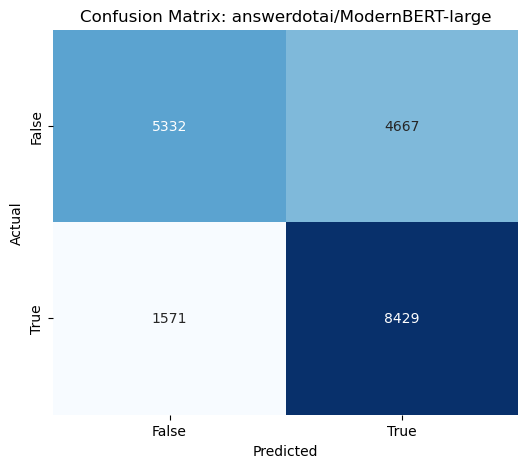

In [29]:
def plot_confusion_matrix(y_true, y_pred, model_id="", labels=[False, True]):

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')

    plt.tight_layout()
    return fig

Create histogram of F1 score for different thresholds

In [25]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

# Cosine similarity of embeddings functions

Evaluate model function

In [20]:
def compute_similarities(train_df, test_df, vectorizer):
    start_time = time.time()
    verification_results = []

    def extract_all_texts(train_df):
        return [t for x in df["pair"] for t in x]

    all_texts = extract_all_texts(train_df)
    vectorizer.fit(all_texts)
    
    for i in tqdm(test_data_df.index, desc="Processing rows"):
        resulting_df_row = {}
        resulting_df_row['id']  = test_data_df.loc[i, 'id']
        resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
        text1 = test_data_df.loc[i, 'pair'][0]
        text2 = test_data_df.loc[i, 'pair'][1]
        
        text1_embedding = vectorizer.transform(text1)
        text2_embedding = vectorizer.transform(text2)

        cosine_similarity_score = F.cosine_similarity(text1_embedding, text2_embedding).item()        
        resulting_df_row['cosine_similarity'] = cosine_similarity_score
        verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Evaluate classification thresholds

In [23]:
def evaluate_classification_thresholds(result_df, classification_thresholds):
    results = []
    y_embeddings = result_df['cosine_similarity']
    y_true = result_df['actual_result']
    for threshold in thresholds:
        y_pred = (result_df["cosine_similarity"] >= threshold).astype(int)
        accuracy, precision, recall, f1 = evaluate_results(y_true, y_pred)
        results.append({
            "threshold": threshold,
            "accuracy" : accuracy,
            "precision" : precision,
            "recall" : recall,
            "f1" : f1
        })
    return pd.DataFrame(results)

# Optuna study function - for cosine similarity of embeddings

In [ ]:
def objective(trial):
    top_f1_trial = -1

    n_gram = trial.suggest_int("n_grams", n_gram_range[0], n_gram_range[1])
    max_features = trial.suggest_categorical("max_features", max_features)
    min_df = trial.suggest_float("min_df", min_df[0], min_df[1])
    lowercase = trial.suggest_categorical("lowercase", lowercase)
    sublinear_tf = trial.suggest_categorical("sublinear_tf", sublinear_tf)
    
    vectorizer = build_tfidf_vectorizer(ngram_range, max_features, min_df, lowercase, sublinear_tf):
    result_df = compute_similarities(train_data_df, test_data_df, vectorizer)

    print(f"Evaluating classification thresholds \n")
    threshold_results_df = evaluate_classification_thresholds(result_df, classification_thresholds)

    top_row = threshold_results_df.sort_values("f1", ascending=False).iloc[0]
    top_threshold = top_row["threshold"]
    top_f1 = top_row["f1"]
    top_accuracy = top_row["accuracy"]
    top_precision = top_row["precision"]
    top_recall = top_row["recall"]

    print(f"Logging results \n")
    print(f"Top threshold: {top_threshold}\n")
    print(f"Top f1: {top_f1}\n")
    print(f"Top accuracy: { top_accuracy}\n")
    print(f"Top precision: {top_precision}\n")
    print(f"Top recall: {top_recall}\n")

    print(f"Used hyperparameters \n")
    print(f"n_gram: {n_gram}\n")
    print(f"max_features: {max_features}\n")
    print(f"min_df: {min_df}\n")
    print(f"lowercase: {lowercase}\n")
    print(f"sublinear_tf: {sublinear_tf}\n")

    trial_results[trial.number] = {
    "metrics": {
        "top_threshold": top_threshold,
        "top_f1": top_f1,
        "top_accuracy": top_accuracy,
        "top_precision": top_precision,
        "top_recall": top_recall
    },
    "hyperparameters": {
        "n_gram": n_gram,
        "max_features": max_features,
        "min_df": min_df,
        "lowercase": lowercase,
        "sublinear_tf": sublinear_tf
        },
    "artifacts" : {
        "threshold_results_df" : threshold_results_df,
        "result_df" : result_df
    }
    }
    
    return top_f1   

# Evaluate cosine embeddings

cosine embedding constants

In [ ]:
classifier = "embedding_cosine_similarity"

Set up the study

In [35]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
trial_results = {}

In [36]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-11 11:34:06,938] Using an existing study with name 'authorship_verification_longformer' instead of creating a new one.


In [ ]:
study.optimize(objective, n_trials=50)

Some weights of LongformerForSequenceClassification were not initialized from the model checkpoint at allenai/longformer-base-4096 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting optuna trial #2 🐻


Epoch 1/1: 100%|██████████| 5000/5000 [34:12<00:00,  2.44it/s]


Optuna trial #2 Epoch 1/1 complete | Loss: 0.6898
Training for the optuna trial 1 complete --- testing the model  



Testing model: 100%|██████████| 2500/2500 [03:12<00:00, 12.97it/s]


...

[I 2025-12-11 19:04:38,135] Trial 7 finished with value: 69.69 and parameters: {'lr': 4.853656556051937e-05, 'epochs': 1, 'batch_size': 4, 'weight_decay': 0.09985071780695223, 'warmup_ratio': 0.5, 'classifier_dropout': 0.13828714661592692}. Best is trial 4 with value: 76.97.


Logging results 

Top threshold: 0.532

Top f1: 69.69

Top accuracy: 53.48

Top precision: 53.48

Top recall: 100.0

Used hyperparameters 

optimizer_learning_rate: 4.853656556051937e-05

weight_decay: 0.09985071780695223

warmup_ratio: 0.5

classifier_dropout: 0.13828714661592692



Some weights of LongformerForSequenceClassification were not initialized from the model checkpoint at allenai/longformer-base-4096 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting optuna trial #9 🐻


Epoch 1/3:  94%|█████████▎| 4683/5000 [32:05<02:10,  2.42it/s]

Load the data from the best trial to variables

In [ ]:
best_trial = study.best_trial
best_trial_data = trial_results[best_trial]

In [ ]:
threshold_results_df = best_trial_data["artifacts"]["threshold_results_df"]
result_df = best_trial_data["result_df"]["result_df"]

top_threshold = best_trial_data["metrics"]["top_threshold"]
top_f1 = best_trial_data["metrics"]["top_f1"]
top_accuracy = best_trial_data["metrics"]["top_accuracy"]
top_precision = best_trial_data["metrics"]["top_precision"]
top_recall = best_trial_data["metrics"]["top_recall"]

top_n_gram = best_trial_data["hyperparameters"]["n_gram"]
top_max_features = best_trial_data["hyperparameters"]["max_features"]
top_min_df = best_trial_data["hyperparameters"]["min_df"]
top_lowercase = best_trial_data["hyperparameters"]["lowercase"]
top_sublinear_tf = best_trial_data["hyperparameters"]["sublinear_tf"]

In [ ]:
y_true = result_df["same"].astype(int).values
y_pred = (y_scores >= top_threshold).astype(int)

Remove all the other artifacts from trial_results before logging

In [ ]:
for trial_id in trial_results:
    if "artifacts" in trial_results[trial_id]:
        del trial_results[trial_id]["artifacts"]

In [ ]:
best_model_path = current_dir.parent.parent / "data" / "02_models" / f"{developer_initials}_{date_str}_{representation_type}_{classifier}_best_model.pkl"

Dump the model

In [ ]:
joblib.dump(vectorizer, best_model_path)

In [ ]:
f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)
f1_threshold_histogram_fig.show()

Confusion matrix

In [ ]:
cm_fig = plot_confusion_matrix(y_true, y_pred, f"{representation_type}_{classifier}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [ ]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{date_str}_{representation_type}_{classifier}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier)
    mlflow.log_table(data=trial_results, artifact_file="trial_results.json")
    
    mlflow.log_param("n_gram", top_n_gram)
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("sublinear_tf", top_sublinear_tf)
    
    mlflow.log_param("classification_score_thresholds", classification_thresholds)
    mlflow.log_table(data=result_df, artifact_file="final_classifier_score_results.json")
    mlflow.log_table(data=threshold_results_df, artifact_file="final_results_for_different_thresholds.json")

    mlflow.log_metric("top_threshold", top_threshold)
    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(f1_threshold_histogram_fig, "final_f1_results_threshold_histogram.png")
    mlflow.log_figure(cm_fig, "final_confusion_matrix.png")

# Classifier config setup for optuna studies

In [5]:
class ClassifierConfig: 
    def __init__(self, classifier_object, searched_hyperparameters, fixed_hyperparameters=None):
        self.classifier_object = classifier_object
        self.searched_hyperparameters = searched_hyperparameters or {}
        self.fixed_hyperparameters = fixed_hyperparameters or {}

    def sample_params(self, trial):
        sampled = {
            name: fn(trial)
            for name, fn in self.searched_hyperparameters.items()
        }
        sampled.update(self.fixed_hyperparameters)
        return sampled

# Optuna study function - for classifiers

In [8]:
def objective(trial, config):
    top_f1_trial = -1

    n_gram = trial.suggest_int("n_grams", n_gram_range[0], n_gram_range[1])
    max_features = trial.suggest_categorical("max_features", max_features)
    min_df = trial.suggest_float("min_df", min_df[0], min_df[1])
    lowercase = trial.suggest_categorical("lowercase", lowercase)
    sublinear_tf = trial.suggest_categorical("sublinear_tf", sublinear_tf)
    
    classifier_params = config.sample_params(trial)
    vectorizer = build_tfidf_vectorizer(ngram_range, max_features, min_df, lowercase, sublinear_tf)

    classifier = config.classifier_object(**classifier_params)
    
    train_data, test_data = build_tfidf_features(vectorizer, train_df, test_df)
    classifier.fit(train_data[0], train_data[1])
    y_pred = classifier.predict(test_data[0])
    y_true = test_data[1]
    top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_true, y_pred)
    
    top_f1 = top_row["f1"]
    top_accuracy = top_row["accuracy"]
    top_precision = top_row["precision"]
    top_recall = top_row["recall"]

    print(f"Logging results \n")
    print(f"Top threshold: {top_threshold}\n")
    print(f"Top f1: {top_f1}\n")
    print(f"Top accuracy: { top_accuracy}\n")
    print(f"Top precision: {top_precision}\n")
    print(f"Top recall: {top_recall}\n")

    print(f"Used hyperparameters \n")
    print(f"n_gram: {n_gram}\n")
    print(f"max_features: {max_features}\n")
    print(f"min_df: {min_df}\n")
    print(f"lowercase: {lowercase}\n")
    print(f"sublinear_tf: {sublinear_tf}\n")

    trial_results[trial.number] = {
    "metrics": {
        "top_f1": top_f1,
        "top_accuracy": top_accuracy,
        "top_precision": top_precision,
        "top_recall": top_recall
    },
    "hyperparameters": {
        "n_gram": n_gram,
        "max_features": max_features,
        "min_df": min_df,
        "lowercase": lowercase,
        "sublinear_tf": sublinear_tf
        },
    "classifier_hyperparameters": {
            **clf_params
    },
    "artifacts" : {
        "y_pred" : y_pred,
        "y_true" : y_true
    }
    }
    
    return top_f1   

# Evaluate model - Multinomial naïve Bayes

In [9]:
classifier = "multinomial_naive_bayes"

In [10]:
multinomial_naive_bayes_config = ClassifierConfig(
    classifier_object=MultinomialNB,
    searched_hyperparameters={
        "alpha": lambda trial: trial.suggest_float("alpha", 1e-3, 1.0, log=True)
    },
    fixed_hyperparameters={}
)

NameError: name 'MultinomialNB' is not defined

Set up the study

In [ ]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

In [ ]:
study.optimize(lambda trial: objective(trial, multinomial_naive_bayes_config), n_trials=50)

Load the data from the best trial to variables

In [ ]:
best_trial = study.best_trial
best_trial_data = trial_results[best_trial]

In [ ]:
result_df = best_trial_data["result_df"]["result_df"]

top_threshold = best_trial_data["metrics"]["top_threshold"]
top_f1 = best_trial_data["metrics"]["top_f1"]
top_accuracy = best_trial_data["metrics"]["top_accuracy"]
top_precision = best_trial_data["metrics"]["top_precision"]
top_recall = best_trial_data["metrics"]["top_recall"]

top_n_gram = best_trial_data["hyperparameters"]["n_gram"]
top_max_features = best_trial_data["hyperparameters"]["max_features"]
top_min_df = best_trial_data["hyperparameters"]["min_df"]
top_lowercase = best_trial_data["hyperparameters"]["lowercase"]
top_sublinear_tf = best_trial_data["hyperparameters"]["sublinear_tf"]

top_alpha = best_trial_data["classifier_hyperparameters"]["alpha"]

In [ ]:
y_true = best_trial_data["artifacts"]["y_true"]
y_pred = best_trial_data["artifacts"]["y_true"]

Remove all the other artifacts from trial_results before logging

In [ ]:
for trial_id in trial_results:
    if "artifacts" in trial_results[trial_id]:
        del trial_results[trial_id]["artifacts"]

In [ ]:
best_model_path = current_dir.parent.parent / "data" / "02_models" / f"{developer_initials}_{date_str}_{representation_type}_{classifier}_best_model.pkl"

Dump the model

In [ ]:
joblib.dump(vectorizer, best_model_path)

In [ ]:
f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)
f1_threshold_histogram_fig.show()

Confusion matrix

In [ ]:
cm_fig = plot_confusion_matrix(y_true, y_pred, f"{representation_type}_{classifier}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [ ]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{date_str}_{representation_type}_{classifier}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier)
    mlflow.log_table(data=trial_results, artifact_file="trial_results.json")
    
    mlflow.log_param("n_gram", top_n_gram)
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("sublinear_tf", top_sublinear_tf)
    
    mlflow.log_param("classification_score_thresholds", classification_thresholds)
    mlflow.log_table(data=result_df, artifact_file="final_classifier_score_results.json")
    mlflow.log_table(data=threshold_results_df, artifact_file="final_results_for_different_thresholds.json")

    mlflow.log_metric("top_threshold", top_threshold)
    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(f1_threshold_histogram_fig, "final_f1_results_threshold_histogram.png")
    mlflow.log_figure(cm_fig, "final_confusion_matrix.png")

# Evaluate model - Logistic regression

In [ ]:
classifier = "logistic_regression"

Resolving the penalty parameter - for both types only certain solvers are possible

In [ ]:
def sample_solver(trial):
    penalty = trial.params["penalty"]

    if penalty == "l1":
        return trial.suggest_categorical("solver", ["liblinear", "saga"])

    if penalty == "l2":
        return trial.suggest_categorical("solver", ["lbfgs", "liblinear", "saga"])

In [ ]:
logigistic_regression_config = ClassifierConfig(
    classifier_object=LogisticRegression,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "penalty": lambda trial: trial.suggest_categorical("penalty", ["l1", "l2"]),
        "solver": sample_solver,
    },
    fixed_hyperparameters={
        "max_iter": 5000,
        "n_jobs": -1 #uses all cores
    }
)

# Evaluate model - Linear SVC

In [ ]:
classifier = "linear_svc"

In [ ]:
linear_svc_config = ClassifierConfig(
    classifier_object=LinearSVC,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "loss": lambda trial: trial.suggest_categorical("loss", ["hinge", "squared_hinge"]),
        "class_weight": lambda trial: trial.suggest_categorical("class_weight", [None, "balanced"]),
    },
    fixed_hyperparameters={
        "penalty": "l2",       # LinearSVC ONLY supports l2
        "dual": True,          # for high-dimensional data (TF-IDF)
        "max_iter": 5000       # ensure convergence
    }
)

# Evaluate model - K-nearest neighbors

In [ ]:
classifier = "k-nearest_neighbors"

In [ ]:
knn_config = ClassifierConfig(
    classifier_object=KNeighborsClassifier,
    searched_hyperparameters={
        "n_neighbors": lambda trial: trial.suggest_int("n_neighbors", 1, 50),
        "weights": lambda trial: trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": lambda trial: trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"]),
    },
    fixed_hyperparameters={
        "algorithm": "auto"
        # optionally: "leaf_size": 30
    }
)

# Evaluate model - Random Forest

In [ ]:
classifier = "random_forest"

In [ ]:
random_forest_config = ClassifierConfig(
    classifier_object=RandomForestClassifier,
    searched_hyperparameters={
        "n_estimators": lambda trial: trial.suggest_int("n_estimators", 100, 600),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 5, 50),
        "min_samples_split": lambda trial: trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": lambda trial: trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": lambda trial: trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        )
    },
    fixed_hyperparameters={
        "n_jobs": -1,        # use all cores
        "random_state": 42   # reproducible forests
    }
)

# Evaluate model - XGBoost

In [ ]:
classifier = "xgboost"

In [ ]:
xgboost_config = ClassifierConfig(
    classifier_object=XGBClassifier,
    searched_hyperparameters={
        "eta": lambda trial: trial.suggest_float("eta", 0.01, 0.3),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 3, 12),
        "subsample": lambda trial: trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": lambda trial: trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": lambda trial: trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": lambda trial: trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
    },
    fixed_hyperparameters={
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_estimators": 300,     
        "tree_method": "gpu_hist", 
        "use_label_encoder": False
    }
)